<a href="https://colab.research.google.com/github/hansi-2000/HR-Project_ML/blob/main/EMP_Attrition_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## IMPORT LIBRARIES ##

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import the required function for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import train and test split function
from sklearn.model_selection import train_test_split

# Import Classifiers to be used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import packages to calculate performance of the models
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score

# To save the model import pickle
import pickle



In [2]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1arzP2ZpZczWWaFjCd9D51b05dJTo7w8z'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1pq5RVhrVYH8f2qXJRgfLpLzio026OvZM'
test = pd.read_csv(test_url)

# Check if the data is loaded correctly
print(train.head())
print(test.head())


   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

  Overtime  Distance from Home    Education Level 

In [3]:
emp_data = pd.concat([train, test], ignore_index=True)

emp_data.info()

emp_data.nunique()

emp_data.isnull().sum()
print()

print("Duplicates: ",emp_data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

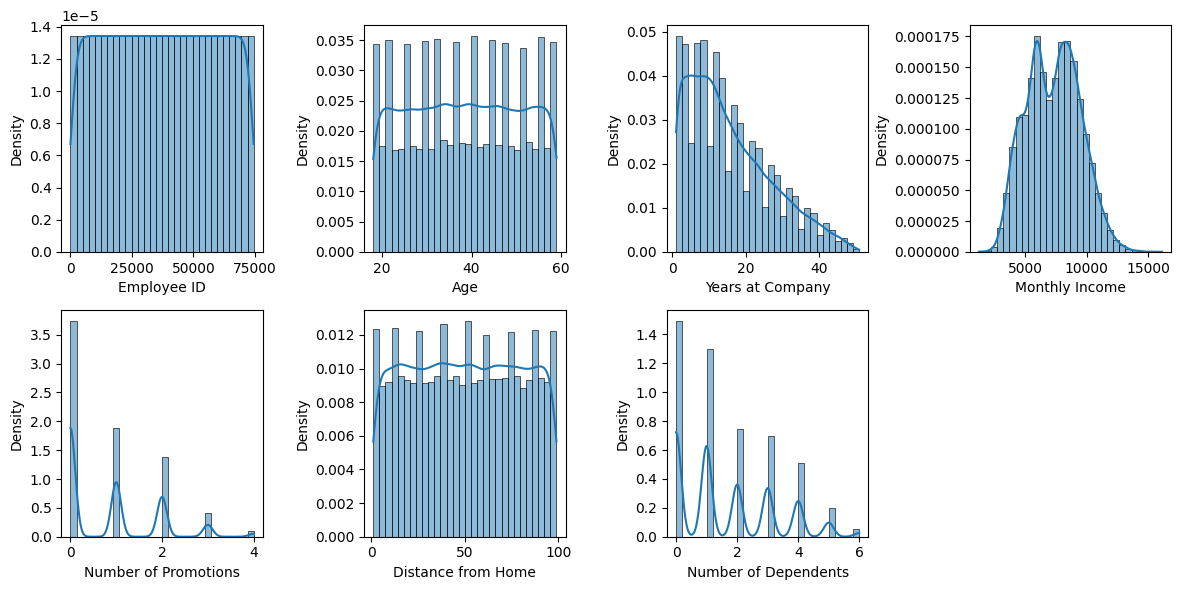

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

emp_eda = emp_data.copy()

# Assuming emp_eda is already defined and contains numeric columns
num_cols_eda = [n for n in emp_eda.columns if emp_eda[n].dtypes != 'O']

# Create a 2x4 grid of subplots (8 subplots total, we'll use 7)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()

# Loop over the first 7 numerical columns and create a histogram for each
for i, col in enumerate(num_cols_eda[:7]):  # Limit to 7 columns
    sns.histplot(emp_eda[col], kde=True, stat='density', bins=30, ax=ax[i])

# Hide the 8th subplot (since we only need 7 plots)
ax[7].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


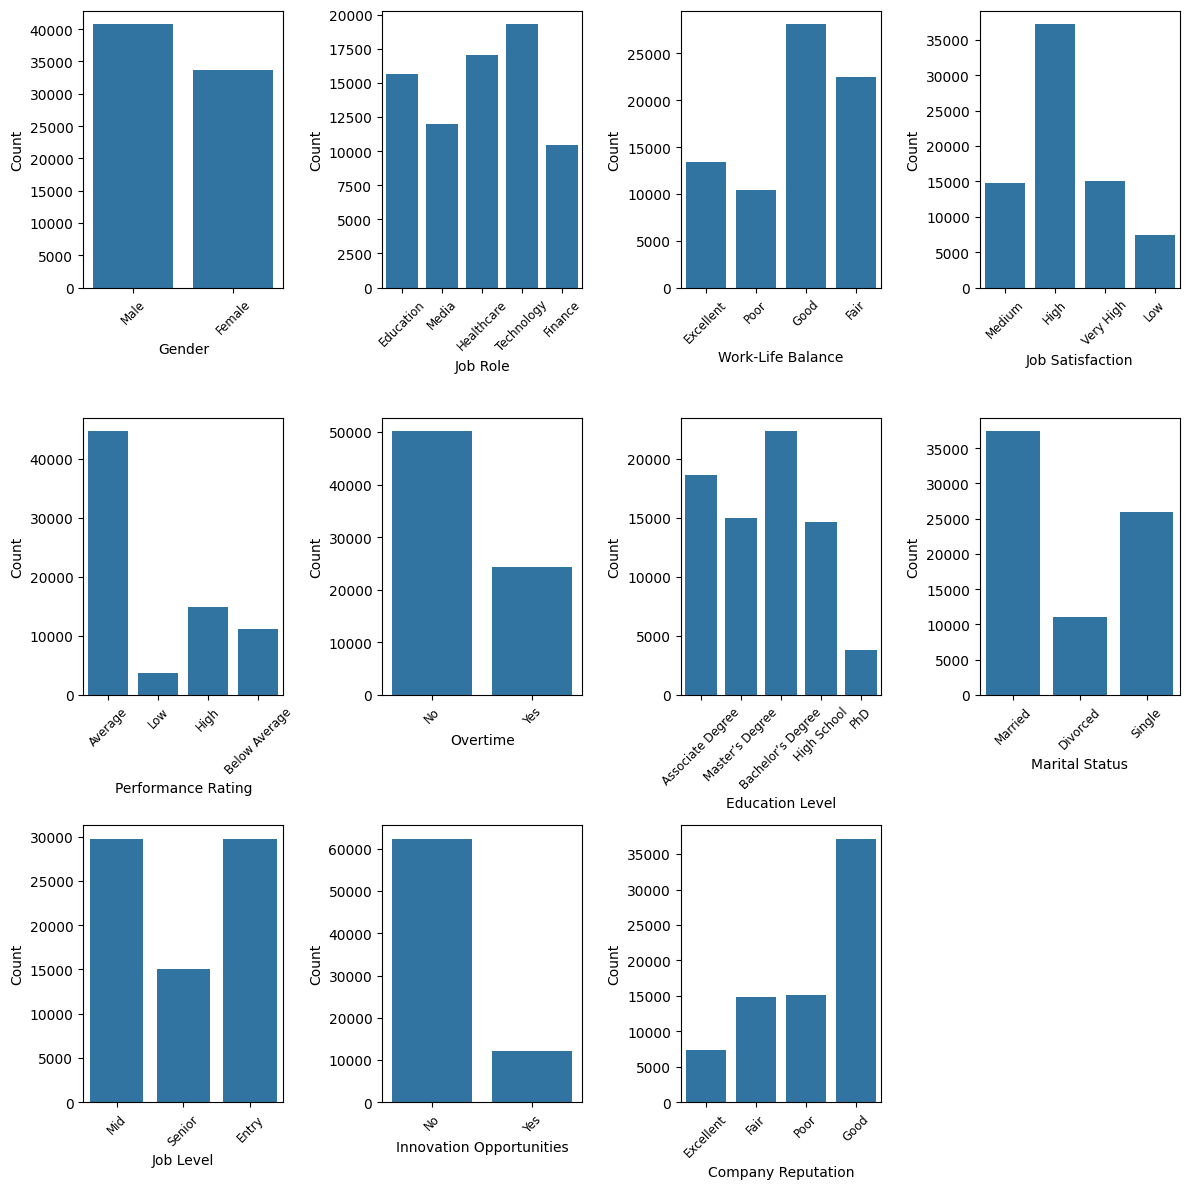

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming emp_eda is already defined and contains categorical columns
cat_cols_eda = [c for c in emp_eda.columns if emp_eda[c].dtypes == 'O']

# Create a 3x4 grid of subplots (12 subplots total)
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop over the first 11 categorical columns and create a countplot for each
for i, col in enumerate(cat_cols_eda[:11]):  # Limit to 11 columns
    sns.countplot(x=col, data=emp_eda, ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].tick_params(axis='x', rotation=45, labelsize=8.5)

# Hide the 12th subplot (since we only need 11 plots)
ax[11].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [21]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1arzP2ZpZczWWaFjCd9D51b05dJTo7w8z'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1pq5RVhrVYH8f2qXJRgfLpLzio026OvZM'
test = pd.read_csv(test_url)

In [22]:
# emp_data.head()
#print(emp_data.columns)

ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
}

for col, mapping in ordinal_mappings.items():
    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)


In [23]:
# print("Unique values in Gender column:", emp_data['Gender'].unique())
binary_columns = ['Innovation Opportunities', 'Overtime', 'Gender', 'Attrition']

binary_mapping = {'No': 0, 'Yes': 1, 'Male': 0, 'Female': 1, 'Stayed':1, 'Left':0}

for col in binary_columns:
    train[col] = train[col].map(binary_mapping)
    test[col] = test[col].map(binary_mapping)

train_df = train.drop(columns=['Job Role', 'Marital Status'])
test_df = test.drop(columns=['Job Role', 'Marital Status'])

train_df.head(10)



,Employee ID,Age,Gender,Years at Company,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Number of Dependents,Job Level,Company Tenure,Innovation Opportunities,Company Reputation,Attrition
0,8410,31,0,19,5390,4,2,3,2,0,22,2,0,2,89,0,4,1
1,64756,59,1,4,5534,1,3,1,3,0,21,4,3,2,21,0,2,1
2,30257,24,1,10,8159,3,3,1,0,0,11,3,3,2,74,0,1,1
3,65791,36,1,7,3989,3,3,4,1,0,27,1,2,2,50,0,3,1
4,65026,56,0,41,4821,2,4,3,0,1,71,1,0,3,68,0,2,1
5,24368,38,1,3,9977,2,3,2,3,0,37,3,0,2,47,1,2,0
6,64970,47,0,23,3681,2,3,4,1,1,75,1,3,1,93,0,3,0
7,36999,48,0,16,11223,4,4,4,2,0,5,4,4,1,88,0,4,1
8,32714,57,0,44,3773,3,2,4,1,1,39,1,4,1,75,0,2,1
9,15944,24,1,1,7319,1,3,3,1,1,57,5,4,1,45,1,3,0


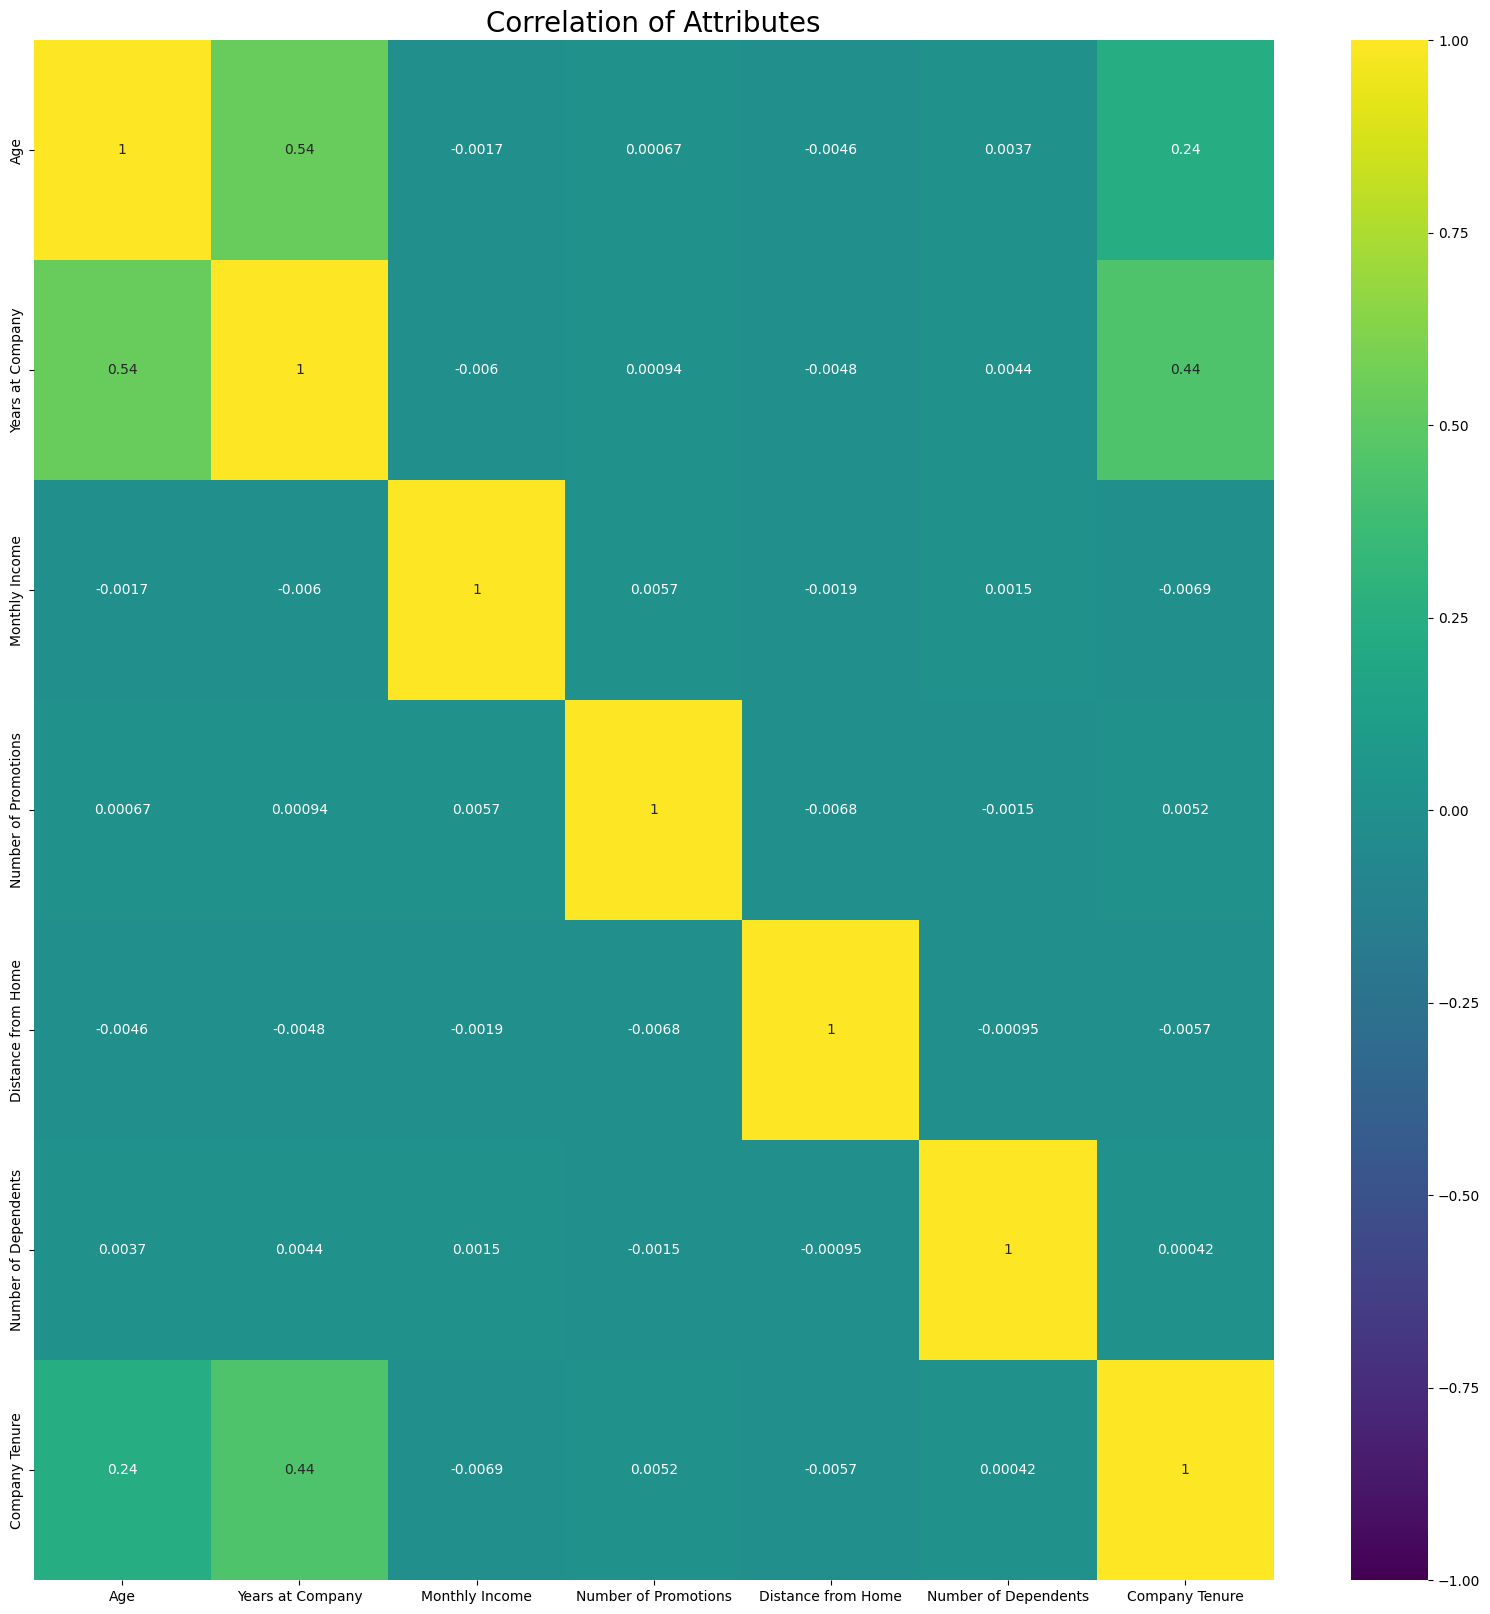

In [9]:
emp_data = emp_data.drop(columns=['Employee ID'])

num_cols = [n for n in emp_data.columns if emp_data[n].dtypes!='O']
colormap = plt.cm.viridis
plt.figure(figsize=(20,20))
plt.title('Correlation of Attributes', size=20)
ax = sns.heatmap(emp_data[num_cols].corr(), cmap=colormap, annot=True, vmin=-1, vmax=1)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Step 2: Separate features and target variable for training
X_train = train_df.drop(columns=['Attrition'])  # Assuming 'Attrition' is the target column
y_train = train_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)  # Convert 'Yes'/'No' to 1/0

# Prepare the test data
X_test = test_df.drop(columns=['Attrition'])
y_test = test_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Step 3: Define the hyperparameter grid for RandomForest
param_grid = {
    'n_estimators': [50, 100],
    'min_samples_split': [10, 20],          # Increased from lower values
    'min_samples_leaf': [4, 8],             # Increased from lower values
    'max_depth': [10, 20, None],            # Limit tree depth to control complexity
    'class_weight': ['balanced_subsample']
}

# Step 4: Perform GridSearchCV to find the best parameters
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

# Step 5: Train the model with the best parameters
best_rf = grid_search.best_estimator_

# Step 6: Evaluate the model on the test data
y_pred = best_rf.predict(X_test)
print("Best Hyperparameters found by GridSearchCV:", grid_search.best_params_)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters found by GridSearchCV: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy on test set: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     14900

    accuracy                           1.00     14900
   macro avg       1.00      1.00      1.00     14900
weighted avg       1.00      1.00      1.00     14900



In [ ]:
from imblearn.over_sampling import SMOTE

# Check for class imbalance in the original train and test data
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

# If the classes are highly imbalanced, apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Combine the resampled training data with the test data for evaluation
X_combined = pd.concat([X_train_resampled, X_test], axis=0)
y_combined = pd.concat([y_train_resampled, y_test], axis=0)

# Check the new distribution after SMOTE
print("New Train class distribution:\n", y_train_resampled.value_counts())
print("Test class distribution:\n", y_test.value_counts())

# Use StratifiedKFold to handle class imbalance
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation with StratifiedKFold
scores = cross_val_score(best_rf, X_combined, y_combined, cv=skf, scoring='f1')
print("Cross-validation F1 scores:", scores)
print("Mean F1 score:", scores.mean())


Train class distribution:
 Attrition
0    59598
Name: count, dtype: int64
Test class distribution:
 Attrition
0    14900
Name: count, dtype: int64


ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

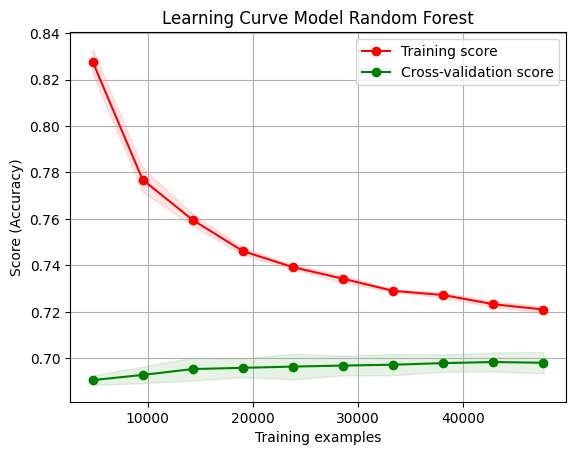

In [24]:
#Import libraries for modelling
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.model_selection import learning_curve, cross_val_score, train_test_split, GridSearchCV
import numpy as np

train = train.drop(columns=['Job Role', 'Marital Status', 'Employee ID'])
X = train.drop(columns=['Attrition'])
y = train['Attrition']

#Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)

#Initializing Random Forest Model
rf = RandomForestClassifier(max_depth=9, n_estimators=100)

# Generating learning curves
# train_sizes: The proportions of the dataset to be used to generate the learning curve
# train_scores: The accuracy scores on the training sets
# test_scores: The accuracy scores on the cross-validation sets
train_sizes, train_scores, test_scores = learning_curve(rf, X, y, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10))

# Calculating the mean and standard deviation of the training scores and the testing scores
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

#Plotting the learning curve
plt.figure()
plt.title("Learning Curve Model Random Forest")
plt.xlabel("Training examples")
plt.ylabel("Score (Accuracy)")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.legend(loc="best")
plt.show()

In [25]:
#Initializing and fitting the Random Forest Model
rf = RandomForestClassifier(max_depth=9, n_estimators=100).fit(X_train, y_train)

#Calculating the accuracy in training and testing
print("Training accuracy =", rf.score(X_train, y_train))
print("Testing accuracy =", rf.score(X_test, y_test))

Training accuracy = 0.7217987439474567
Testing accuracy = 0.6944630872483222


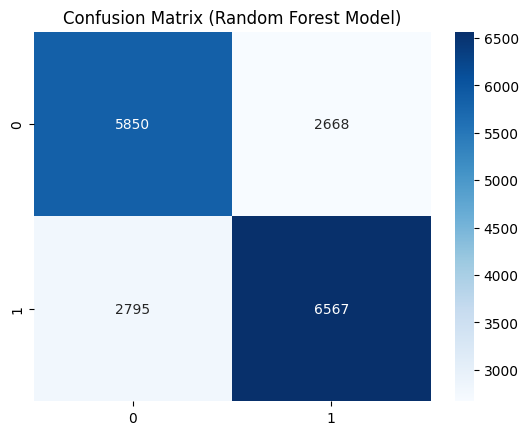

In [26]:
#Make a prediction using Decision Tree
y_pred = rf.predict(X_test)

#Creat a confusion matrix to evaluate the model
cmatrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cmatrix, annot=True, cmap='Blues', fmt='g')
plt.title("Confusion Matrix (Random Forest Model)")
plt.show()

In [27]:
#Display the classification report for Random Forest
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.69      0.68      8518
           1       0.71      0.70      0.71      9362

    accuracy                           0.69     17880
   macro avg       0.69      0.69      0.69     17880
weighted avg       0.69      0.69      0.69     17880



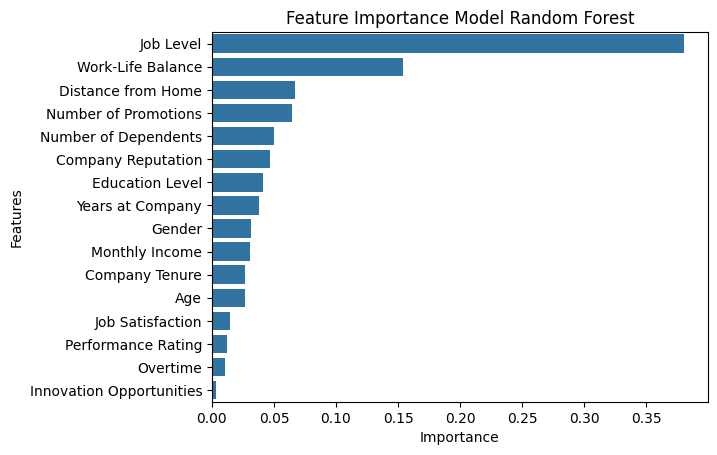

In [28]:
#Extract feature importances
imp = pd.DataFrame()
imp['Features'] = X.columns
imp['Importance'] = rf.feature_importances_
imp = imp.sort_values(by='Importance', ascending=False)

#Plot the feature importances
sns.barplot(imp, y='Features', x='Importance')
plt.title("Feature Importance Model Random Forest")
plt.show()

<Figure size 1000x600 with 0 Axes>

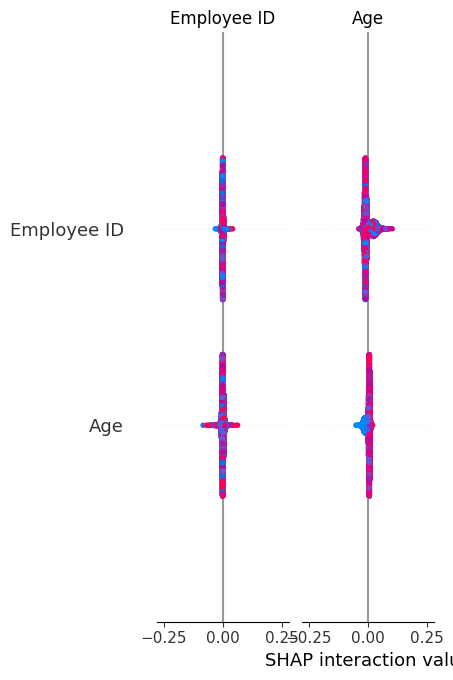

<Figure size 1000x600 with 0 Axes>

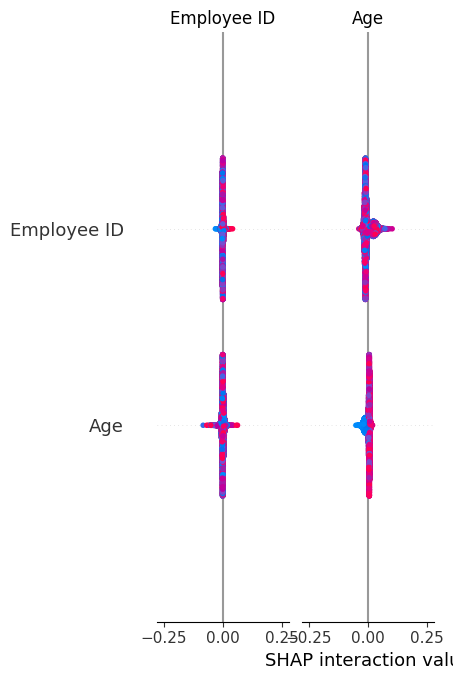

In [19]:
!pip install shap

import shap
import matplotlib.pyplot as plt

# Train your model (if not already trained)
rf = RandomForestClassifier(max_depth=9, n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Create a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

# Select the SHAP values for the positive class (assuming binary classification)
shap_values_positive = shap_values[1] if len(shap_values) == 2 else shap_values

# Plot the summary plot of SHAP values
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_positive, X_test, plot_type="bar")

# Show a more detailed summary plot (beeswarm plot) to see feature impacts per instance
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_positive, X_test)
